<a href="https://colab.research.google.com/github/NomNomNarang/Image-Classification-ANN/blob/main/graduate_admission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense

In [4]:
df=pd.read_csv('Admission_Predict_Ver1.1.csv')

In [5]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [11]:
df.drop(columns=['Serial No.'])

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1,0.87
496,337,117,5,5.0,5.0,9.87,1,0.96
497,330,120,5,4.5,5.0,9.56,1,0.93
498,312,103,4,4.0,5.0,8.43,0,0.73


In [12]:
x=df.iloc[:,0:-1]

In [13]:
y=df.iloc[:,-1]

In [14]:
x

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,1,337,118,4,4.5,4.5,9.65,1
1,2,324,107,4,4.0,4.5,8.87,1
2,3,316,104,3,3.0,3.5,8.00,1
3,4,322,110,3,3.5,2.5,8.67,1
4,5,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1
496,497,337,117,5,5.0,5.0,9.87,1
497,498,330,120,5,4.5,5.0,9.56,1
498,499,312,103,4,4.0,5.0,8.43,0


In [15]:
y

,Chance of Admit
0,0.92
1,0.76
2,0.72
3,0.80
4,0.65
...,...
495,0.87
496,0.96
497,0.93
498,0.73


In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [17]:
x_train.shape

(400, 8)

In [19]:
x_test.shape

(100, 8)

In [20]:
y_train.shape

(400,)

In [21]:
y_test.shape

(100,)

In [22]:
x_train

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
107,108,338,117,4,3.5,4.5,9.46,1
336,337,319,110,3,3.0,2.5,8.79,0
71,72,336,112,5,5.0,5.0,9.76,1
474,475,308,105,4,3.0,2.5,7.95,1
6,7,321,109,3,3.0,4.0,8.20,1
...,...,...,...,...,...,...,...,...
323,324,305,102,2,2.0,2.5,8.18,0
192,193,322,114,5,4.5,4.0,8.94,1
117,118,290,104,4,2.0,2.5,7.46,0
47,48,339,119,5,4.5,4.0,9.70,0


In [23]:
##scaling is just as Normalization
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [24]:
x_train

array([[0.21442886, 0.96      , 0.89285714, ..., 0.875     , 0.8525641 ,
        1.        ],
       [0.67334669, 0.58      , 0.64285714, ..., 0.375     , 0.63782051,
        0.        ],
       [0.14228457, 0.92      , 0.71428571, ..., 1.        , 0.94871795,
        1.        ],
       ...,
       [0.23446894, 0.        , 0.42857143, ..., 0.375     , 0.21153846,
        0.        ],
       [0.09418838, 0.98      , 0.96428571, ..., 0.75      , 0.92948718,
        0.        ],
       [0.34468938, 0.64      , 0.64285714, ..., 1.        , 0.74679487,
        1.        ]])

In [50]:
model=keras.Sequential([
    layers.Dense(7,input_dim=8,activation='relu'),
    layers.Dense(7,activation='relu'),
    layers.Dense(1,activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['accuracy']
)

In [74]:
history=model.fit(x_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.0000e+00 - loss: 0.0026 - val_accuracy: 0.0000e+00 - val_loss: 0.0027
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: 0.0026 - val_accuracy: 0.0000e+00 - val_loss: 0.0028
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0000e+00 - loss: 0.0026 - val_accuracy: 0.0000e+00 - val_loss: 0.0027
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0000e+00 - loss: 0.0027 - val_accuracy: 0.0000e+00 - val_loss: 0.0028
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.0000e+00 - loss: 0.0028 - val_accuracy: 0.0000e+00 - val_loss: 0.0028
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.0000e+00 - loss: 0.0028 - val_accuracy: 0.0000e+00 - val_loss: 0.0028
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0000e+00 - loss: 0.0034 - val_accuracy: 0.0000e+00 - val_loss: 0.0028
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/s

In [75]:
y_pred=model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [76]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7861497691296876

In [77]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)

0.0037348408195922883

In [78]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

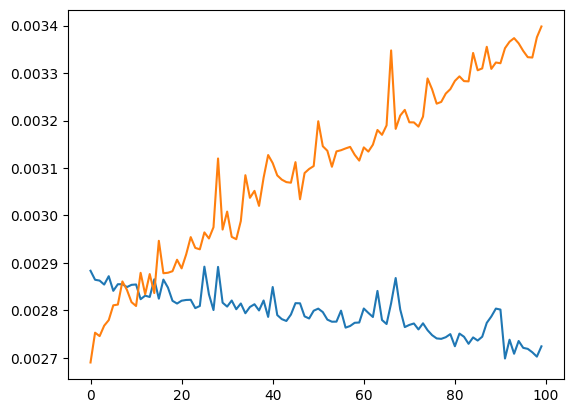

In [79]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [84]:
history.history['val_loss']

[0.0026900272350758314,
 0.0027528032660484314,
 0.002745595294982195,
 0.002767592668533325,
 0.0027793277986347675,
 0.0028105166275054216,
 0.002812074264511466,
 0.0028608576394617558,
 0.0028429259546101093,
 0.002817172557115555,
 0.0028090854175388813,
 0.0028790305368602276,
 0.0028337587136775255,
 0.002876415615901351,
 0.002836409490555525,
 0.002946518361568451,
 0.0028781513683497906,
 0.002879164647310972,
 0.0028824214823544025,
 0.0029066007118672132,
 0.0028884015046060085,
 0.002917769830673933,
 0.002954291645437479,
 0.0029315350111573935,
 0.0029285771306604147,
 0.0029642467852681875,
 0.0029514003545045853,
 0.0029751071706414223,
 0.003120053792372346,
 0.0029702158644795418,
 0.0030080978758633137,
 0.0029548066668212414,
 0.002949848771095276,
 0.002988243941217661,
 0.00308477645739913,
 0.003037084825336933,
 0.0030517918057739735,
 0.0030201112385839224,
 0.003079409711062908,
 0.003127277595922351,
 0.0031103496439754963,
 0.003084373427554965,
 0.00307542

In [89]:
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print("Train Loss:", train_loss)
print("Val Loss:", val_loss)
print("Is val_loss > loss?", val_loss > train_loss)


Train Loss: 0.0027240554336458445
Val Loss: 0.0033982961904257536
Is val_loss > loss? True
